[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/SARSA_Semi_Gradiente.ipynb)

## **1. SARSA Semi Gradiente para el entorno MountainCarContinuous**

### Clonado de repositorio y ubicación en directorio correcto

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/Entornos_Complejos/
%ls

### Instalación de dependencias

In [ ]:
# %%capture
## Instalación de algunos paquetes.
%pip install swig numpy matplotlib gymnasium
%pip install "gymnasium[classic-control]"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importado de librerias

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import os

from src.experiment.sarsa_functions import semi_gradient_sarsa, pi_star_from_Q, plot, plot_episodes_length, plot_policy_episodes

### Replicabilidad

In [3]:
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

name = 'MountainCarContinuous-v0' # Cambiar según el entorno deseado

### Generación de entorno

In [4]:
#@title Importamos MountainCarContinuous
env = gym.make(name, render_mode="rgb_array")
env.reset(seed=seed)

(array([-0.46483374,  0.        ], dtype=float32), {})

## **3. Experimentación**  

In [6]:
w1, Q1, list_stats, list_episodes_length = semi_gradient_sarsa(
    env,
    num_episodes=5000,
    epsilon=0.4,
    decay=True,
    discount_factor=0.99,
    alpha=0.01
)

 10%|█         | 507/5000 [00:15<01:02, 71.92it/s]

Episodio 500 -> Reward medio acumulado: 53.4202, Epsilon: 0.0500


 20%|██        | 1014/5000 [00:23<00:26, 148.62it/s]

Episodio 1000 -> Reward medio acumulado: 65.0161, Epsilon: 0.0500


 30%|███       | 1521/5000 [00:27<00:38, 90.47it/s] 

...

Episodio 4000 -> Reward medio acumulado: 85.9703, Epsilon: 0.0500


 90%|█████████ | 4525/5000 [00:53<00:03, 153.49it/s]

Episodio 4500 -> Reward medio acumulado: 86.7711, Epsilon: 0.0500


100%|██████████| 5000/5000 [00:56<00:00, 88.56it/s] 

Proporción final de Reward: 87.4216


#### Evaluación

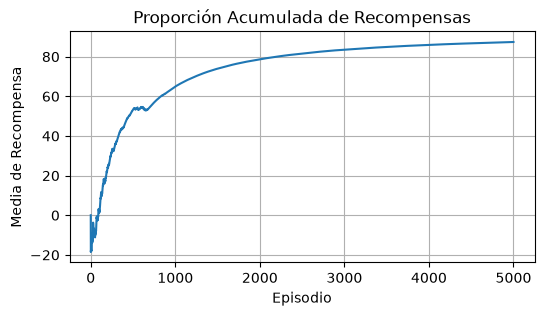

Máxima proporcion: 87.40408360226344


In [7]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

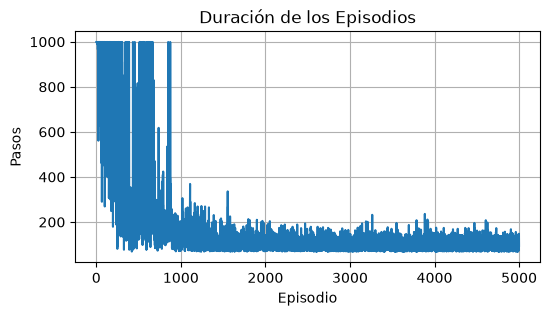

Máximo tamaño de episodio: 999


In [8]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [ ]:
pi, actions = pi_star_from_Q(env, Q1)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Render del entorno\n", env.render())

Política óptima obtenida
 Política completada con Recompensa Total: 94.41500000953674 
 Acciones -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500, -0.500... 
 Render del entorno
 [[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


### Segunda ejecución entorno MountainCarContinuous

In [10]:
w2, Q, list_stats, list_episodes_length = semi_gradient_sarsa(
    env,
    num_episodes=5000,
    epsilon=1,
    decay=True,
    discount_factor=0.95,
    alpha=0.005
)

 10%|█         | 503/5000 [00:26<04:15, 17.57it/s]

Episodio 500 -> Reward medio acumulado: -5.5388, Epsilon: 0.0500


 20%|██        | 1003/5000 [00:52<03:37, 18.41it/s]

Episodio 1000 -> Reward medio acumulado: -3.9615, Epsilon: 0.0500


 30%|███       | 1503/5000 [01:19<02:58, 19.64it/s]

...

Episodio 4000 -> Reward medio acumulado: -2.7551, Epsilon: 0.0500


 90%|█████████ | 4503/5000 [04:03<00:29, 16.87it/s]

Episodio 4500 -> Reward medio acumulado: -2.7140, Epsilon: 0.0500


100%|██████████| 5000/5000 [04:30<00:00, 18.51it/s]

Proporción final de Reward: -2.6802


#### Evaluación

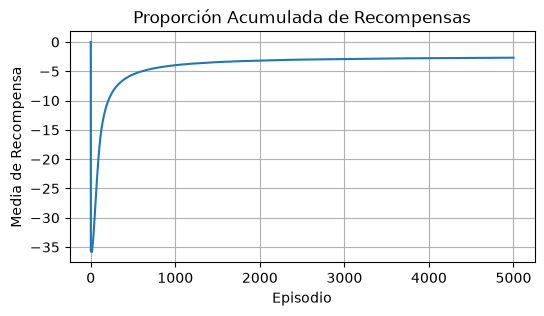

Máxima proporcion: -2.679623218466788


In [11]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

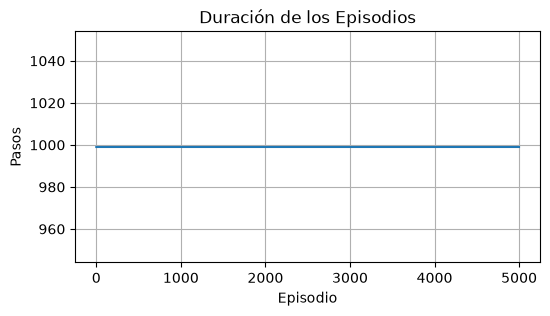

Máximo tamaño de episodio: 999


In [12]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [ ]:
# @title Política final MountainCarContinuous
pi, actions = pi_star_from_Q(env, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Render del entorno\n", env.render())

Política óptima obtenida
 Política completada con Recompensa Total: 0.0 
 Acciones 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000... 
 Render del entorno
 [[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


In [14]:
plot_policy_episodes(Q1, 1)